# 第 6 章　支援向量機（SVM）— 實作 Notebook

本 notebook 搭配網站「醫學生的機器學習入門」第 6 章。可直接在 Google Colab 執行（選單「執行階段 → 全部執行」），不需要安裝額外套件，也不需要下載資料（使用 scikit-learn 內建的 WDBC 乳癌資料集）。

- 圖上的標籤用英文，是因為 Colab 預設沒有中文字型。
- 醫學資料部分僅供學習，不構成臨床建議。

先印出套件版本。本教材以 Colab 現況（scikit-learn 1.6.x）為底線，也在較新版本測試過。

In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

Python 3.12.2
numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 先用 2D 玩具資料看直覺：C 與 gamma

`make_moons` 產生兩個交錯的月牙形，是非線性邊界的經典範例。下面固定 RBF 核，改變 C（對越界的處罰）與 gamma（每個點的影響半徑），看決策邊界怎麼變。

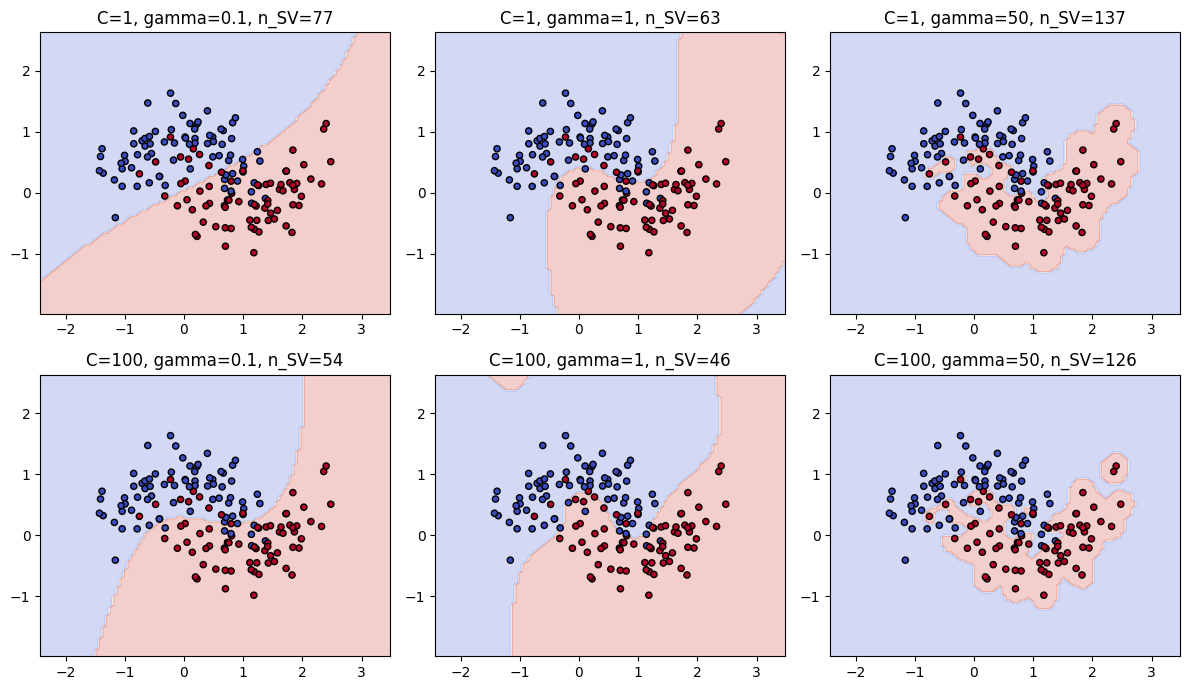

In [2]:
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

X_toy, y_toy = make_moons(n_samples=150, noise=0.3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, C in zip(axes, [1, 100]):
    for ax, gamma in zip(row, [0.1, 1, 50]):
        clf = SVC(kernel="rbf", C=C, gamma=gamma).fit(X_toy, y_toy)
        DecisionBoundaryDisplay.from_estimator(
            clf, X_toy, response_method="predict", cmap="coolwarm", alpha=0.25, ax=ax)
        ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap="coolwarm", edgecolor="k", s=20)
        ax.set_title(f"C={C}, gamma={gamma}, n_SV={clf.n_support_.sum()}")
plt.tight_layout()
plt.show()

gamma 愈大，邊界愈彎、愈會繞著個別點畫圈；C 愈大，模型愈不願意讓訓練點落在錯的一邊。右下角（C 與 gamma 都大）就是典型的過擬合。

## 2. 載入 WDBC 乳癌資料

569 位病人、30 個細胞核影像特徵。**注意 sklearn 的編碼：0 = malignant（惡性）、1 = benign（良性）**，和直覺相反，所以先印出 `target_names` 確認。

In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print("X shape:", X.shape)
print("target_names:", data.target_names.tolist())  # index 0 = malignant, 1 = benign
print(y.map(dict(enumerate(data.target_names.tolist()))).value_counts())

X shape: (569, 30)
target_names: ['malignant', 'benign']
target
benign       357
malignant    212
Name: count, dtype: int64


先切出測試集，之後所有調整都只在訓練集上做。`stratify=y` 讓兩邊的惡性比例一致。

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(len(X_train), "train /", len(X_test), "test")

426 train / 143 test


## 3. 故意做錯：不標準化直接丟進 SVM

WDBC 的 `worst area` 可以到幾千，`mean smoothness` 只有零點幾。SVM 靠「距離」運作，尺度大的特徵會主導一切。比較一下有沒有 `StandardScaler` 的差別。

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

raw = SVC().fit(X_train, y_train)
scaled = make_pipeline(StandardScaler(), SVC()).fit(X_train, y_train)
print(f"No scaling  : test accuracy = {raw.score(X_test, y_test):.3f}")
print(f"With scaling: test accuracy = {scaled.score(X_test, y_test):.3f}")

No scaling  : test accuracy = 0.923
With scaling: test accuracy = 0.979


標準化放在 `Pipeline` 裡，交叉驗證時每一折都只用該折的訓練資料算平均與標準差，避免資料洩漏。

## 4. 比較三種核函數

用訓練集做 5 折交叉驗證，比較 linear、poly、rbf 三種核（其他參數用預設值）。

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for kernel in ["linear", "poly", "rbf"]:
    model = make_pipeline(StandardScaler(), SVC(kernel=kernel))
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{kernel:>6}: CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

linear: CV accuracy 0.972 ± 0.012
  poly: CV accuracy 0.894 ± 0.036
   rbf: CV accuracy 0.967 ± 0.005


linear 與 rbf 的分數很接近（差距在標準差範圍內），poly（預設 degree=3）明顯較低。在這份資料上，線性核已經很夠用；「核函數愈複雜愈好」並不成立。

## 5. 支援向量有幾個？

In [7]:
svc = scaled.named_steps["svc"]
print("Support vectors per class:", dict(zip(data.target_names.tolist(), svc.n_support_.tolist())))
print("Total:", svc.n_support_.sum(), "of", len(X_train), "training samples")

Support vectors per class: {'malignant': 50, 'benign': 46}
Total: 96 of 426 training samples


## 6. 用 GridSearchCV 找 C 與 gamma（第 11 章會細講）

`svc__C` 的寫法是「Pipeline 裡名叫 svc 的步驟的 C 參數」。

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.001, 0.01, 0.1, 1]}
search = GridSearchCV(make_pipeline(StandardScaler(), SVC()), param_grid, cv=cv)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print(f"Best CV accuracy: {search.best_score_:.3f}")
print(f"Test accuracy   : {search.score(X_test, y_test):.3f}")

Best params: {'svc__C': 10, 'svc__gamma': 0.001}
Best CV accuracy: 0.974
Test accuracy   : 0.979


把 16 組參數的交叉驗證分數排成表，可以看到 gamma 太大（1）時分數明顯掉下來。

In [9]:
res = pd.DataFrame(search.cv_results_)
table = res.pivot_table(index="param_svc__C", columns="param_svc__gamma", values="mean_test_score")
print(table.round(3))

param_svc__gamma  0.001  0.010  0.100  1.000
param_svc__C                                
0.1               0.706  0.948  0.944  0.627
1.0               0.946  0.965  0.960  0.631
10.0              0.974  0.972  0.946  0.631
100.0             0.970  0.963  0.946  0.631


## 7. 混淆矩陣：惡性漏掉幾個？

臨床上最在意的是把惡性判成良性（偽陰性）。`classification_report` 裡 malignant 那一列的 recall 就是「惡性的敏感度」。

              precision    recall  f1-score   support

   malignant      0.981     0.962     0.971        53
      benign      0.978     0.989     0.983        90

    accuracy                          0.979       143
   macro avg      0.979     0.976     0.977       143
weighted avg      0.979     0.979     0.979       143



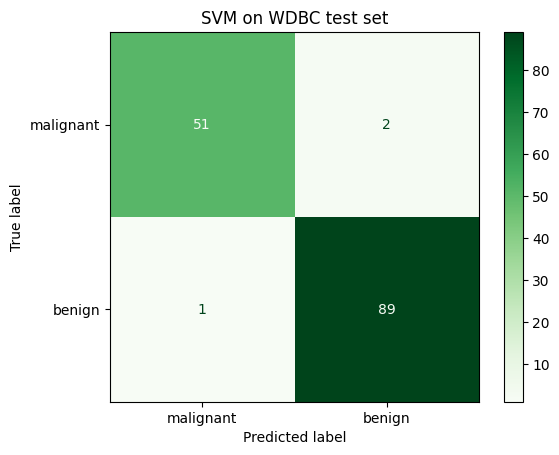

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best = search.best_estimator_
y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names, digits=3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=data.target_names, cmap="Greens")
plt.title("SVM on WDBC test set")
plt.show()

## 8. SVM 的「分數」不是機率

`decision_function` 給的是「離邊界多遠」（有正負號），不是機率。在這份資料，正值偏向 benign（類別 1）、負值偏向 malignant（類別 0）。

In [11]:
print("decision_function:", best.decision_function(X_test.iloc[:5]).round(2))
print("true labels      :", y_test.iloc[:5].map(dict(enumerate(data.target_names.tolist()))).tolist())

decision_function: [ 1.04 -2.06  0.19  0.79  0.05]
true labels      : ['benign', 'malignant', 'benign', 'benign', 'malignant']


真的需要機率時，用 `CalibratedClassifierCV` 另外做校準（不要用已被標為即將移除的 `SVC(probability=True)`）。

In [12]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(search.best_estimator_, ensemble=False, cv=5)
calibrated.fit(X_train, y_train)
proba_malignant = calibrated.predict_proba(X_test.iloc[:5])[:, 0]
print("P(malignant):", proba_malignant.round(3))

P(malignant): [0.06  0.999 0.471 0.123 0.577]


## 動手試試

1. 在第 1 節把 `gamma` 改成 `[0.01, 5, 200]`，觀察邊界怎麼從「一條直線」變成「一顆顆小島」；再把 C 改成 0.01 看看支援向量數量。
2. 在第 6 節的 `SVC()` 裡加上 `class_weight="balanced"`，重新跑第 6、7 節，比較 malignant 的 recall 有沒有變化。
3. 把第 4 節的 `StandardScaler()` 拿掉（直接 `SVC(kernel=kernel)`），看看哪一種核受影響最大。提示：linear 核在未標準化時可能跑很久，可先只試 rbf。